# Adult Income
Data Analysis - ISAE 2025/2026

In [20]:
import os

import loguru
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [21]:
data_path = "./data/"
data_file = os.path.join(data_path, "adult_sample.csv")
loguru.logger.info(f"Loading data from {data_file}")

2026-01-28 10:20:18.273 | INFO     | __main__:<module>:3 - Loading data from ./data/adult_sample.csv


## 1 - Data import

In [22]:
# Load data and labels
df = pd.read_csv(
    data_file,
    header=None,
    names=[
        "age",
        "workclass",
        "education",
        "education-num",
        "occupation",
        "relationship",
        "race",
        "sex",
        "capital-gain",
        "capital-loss",
        "hours-per-week",
        "native-country",
        "income",
    ],
)
df.sample(10)  # Let's take a random sample from the full data frame

,age,workclass,education,education-num,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
212,29.0,Private,HS-grad,9,Exec-managerial,Unmarried,Black,Female,0.0,0,40,United-States,<=50K
1029,20.0,Self-emp-not-inc,HS-grad,9,Transport-moving,Own-child,White,Male,0.0,0,80,United-States,<=50K
880,47.0,Private,5th-6th,3,Priv-house-serv,Own-child,White,Female,0.0,0,40,El-Salvador,<=50K
547,27.0,Private,HS-grad,9,Farming-fishing,Own-child,White,Female,0.0,0,40,Mexico,<=50K
20,28.0,Private,HS-grad,9,Exec-managerial,Not-in-family,White,Male,0.0,0,40,United-States,<=50K
1783,41.0,Self-emp-not-inc,HS-grad,9,Exec-managerial,Husband,White,Male,0.0,0,45,Mexico,<=50K
565,41.0,Private,Doctorate,16,Prof-specialty,Husband,White,Male,0.0,0,50,United-States,>50K
117,42.0,Private,Bachelors,13,Sales,Wife,White,Female,0.0,0,40,Puerto-Rico,<=50K
1047,27.0,Private,Some-college,10,Exec-managerial,Husband,White,Male,0.0,0,60,United-States,<=50K
858,24.0,Private,HS-grad,9,Handlers-cleaners,Not-in-family,White,Male,0.0,0,40,United-States,<=50K


## 2 - Data analysis

In [23]:
df.info()  # quick information concerning the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967 entries, 0 to 1966
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1917 non-null   float64
 1   workclass       1842 non-null   object 
 2   education       1967 non-null   object 
 3   education-num   1967 non-null   int64  
 4   occupation      1842 non-null   object 
 5   relationship    1967 non-null   object 
 6   race            1967 non-null   object 
 7   sex             1967 non-null   object 
 8   capital-gain    1932 non-null   float64
 9   capital-loss    1967 non-null   int64  
 10  hours-per-week  1967 non-null   int64  
 11  native-country  1967 non-null   object 
 12  income          1967 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 199.9+ KB


In [24]:
numerical_features = [col for col in df.columns if df[col].dtype in ["int64", "float64"]]
categorical_features = [col for col in df.columns if col not in numerical_features]
loguru.logger.info(f"Numerical features: {numerical_features}")
loguru.logger.info(f"Categorical features: {categorical_features}")

# One-hot encode categorical features
loguru.logger.info("One-hot encoding categorical features")
encoder = OneHotEncoder(handle_unknown="ignore", drop="if_binary")
categorical_encoded = encoder.fit_transform(df[categorical_features])
categorical_cols = encoder.get_feature_names_out(categorical_features)
categorical_encoded_df = pd.DataFrame(categorical_encoded.toarray(), columns=categorical_cols)
enumerated_cat_cols = zip(range(len(categorical_cols)), categorical_cols)
loguru.logger.info(f"Categorical features encoded: {list(enumerated_cat_cols)}")

# Scale numerical features
loguru.logger.info("Scaling numerical features")
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df[numerical_features])

# Combine numerical and encoded categorical features
df_processed = pd.concat(
    [
        pd.DataFrame(numerical_scaled, columns=numerical_features).reset_index(drop=True),
        categorical_encoded_df.reset_index(drop=True),
    ],
    axis=1,
)
loguru.logger.info(f"Processed DataFrame from shape {df.shape}, to shape {df_processed.shape}")

2026-01-28 10:20:18.363 | INFO     | __main__:<module>:3 - Numerical features: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
2026-01-28 10:20:18.364 | INFO     | __main__:<module>:4 - Categorical features: ['workclass', 'education', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
2026-01-28 10:20:18.365 | INFO     | __main__:<module>:7 - One-hot encoding categorical features
2026-01-28 10:20:18.380 | INFO     | __main__:<module>:15 - Categorical features encoded: [(0, 'workclass_ Federal-gov'), (1, 'workclass_ Local-gov'), (2, 'workclass_ Private'), (3, 'workclass_ Self-emp-inc'), (4, 'workclass_ Self-emp-not-inc'), (5, 'workclass_ State-gov'), (6, 'workclass_ Without-pay'), (7, 'workclass_nan'), (8, 'education_ 10th'), (9, 'education_ 11th'), (10, 'education_ 12th'), (11, 'education_ 1st-4th'), (12, 'education_ 5th-6th'), (13, 'education_ 7th-8th'), (14, 'education_ 9th'), (15, 'education_ Assoc-acdm'), (16, 'education_ Assoc-voc')

In [25]:
# Show NaNs info
df_nan = df_processed[df_processed.isna().any(axis=1)]
nan_count = df_processed.isna().sum().sum()
loguru.logger.info(f"There are {nan_count} in the processed DataFrame.")
df_processed = df_processed.dropna(axis=0)
df_nan.head()

2026-01-28 10:20:18.411 | INFO     | __main__:<module>:4 - There are 85 in the processed DataFrame.


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Philippines,native-country_ Poland,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ United-States,native-country_ Vietnam,income_ >50K
6,NaN,-1.158607,-0.125264,-0.217189,-0.001465,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
13,2.544550,1.259409,NaN,-0.217189,-0.801997,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
16,0.960605,1.662412,NaN,-0.217189,0.799067,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
76,NaN,-3.576624,-0.125264,-0.217189,-0.001465,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
82,1.536585,-0.352602,NaN,-0.217189,-1.922742,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


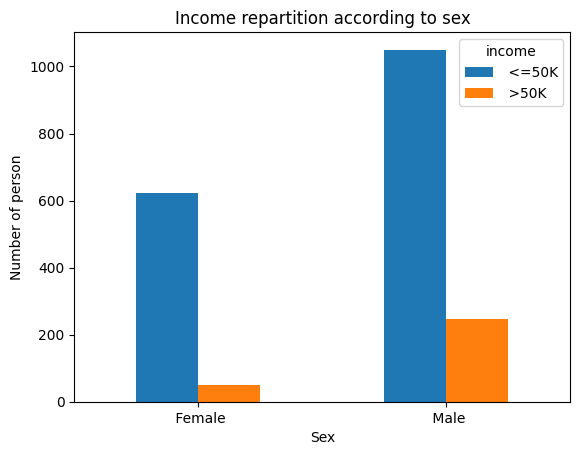

In [26]:
# Let's analyze one feature (sex) according to the label (income)
counts = df.groupby(["sex", "income"]).size().unstack()

# Let's display the graphic
counts.plot(kind="bar", stacked=False)
plt.title("Income repartition according to sex")
plt.ylabel("Number of person")
plt.xlabel("Sex")
plt.xticks(rotation=0)
plt.show()

2026-01-28 10:20:23.462 | INFO     | __main__:<module>:4 - Explained variance ratio: [0.16487657 0.12003857]
2026-01-28 10:20:23.465 | INFO     | __main__:<module>:5 - Singular values: [51.66931011 44.08731002]


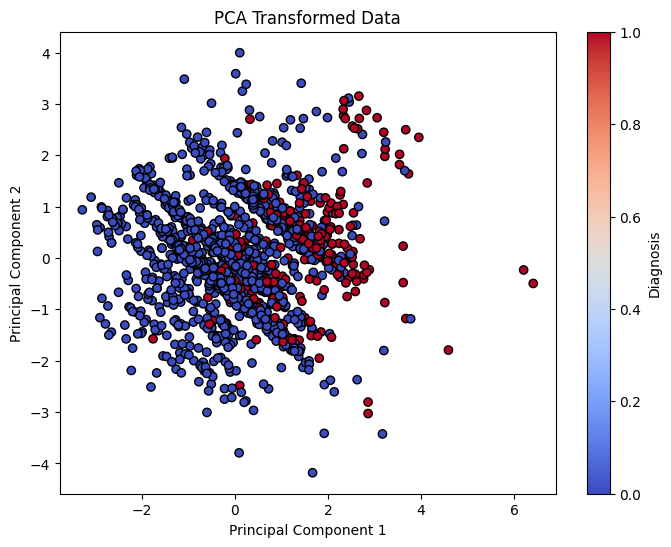

In [28]:
X = df_processed.to_numpy()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
loguru.logger.info(f"Explained variance ratio: {pca.explained_variance_ratio_}")
loguru.logger.info(f"Singular values: {pca.singular_values_}")

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=df_processed["income_ >50K"], cmap="coolwarm", edgecolor="k"
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label="Diagnosis")
plt.show()